# Deep Learning Basics

**Objectives**
* Use TensorFlow to create simple network architectures
* Understand the basics of creating a Deep Learning solution to a problem 

## Dataset

We will use the "[OCR dataset](http://ai.stanford.edu/~btaskar/ocr/)" collected by the MIT Spoken Language System Groups, which contains handwritten letters. For ease of use, the data has already been put into Numpy arrays and can be loaded directly into the Notebook or any Python script from the "letters_X.npy" and "letters_Y.npy" files.

The dataset contains 52152 letters. The letters_X.npy file contains the 16x8 pixels images (flattened to a 128-size vector), and the letters_Y.npy file contains the supervision, with for each letter a 26-size binary vector. The letter "A" would be represented by a "1" at position 0 in the vector ([1 0 0 0 ... 0]), whereas the letter "Z" would be represented by a "1" at position 25 ([0 0 0 ... 0 1]). The following code loads the 64 first letters in the dataset and displays the images and supervision.

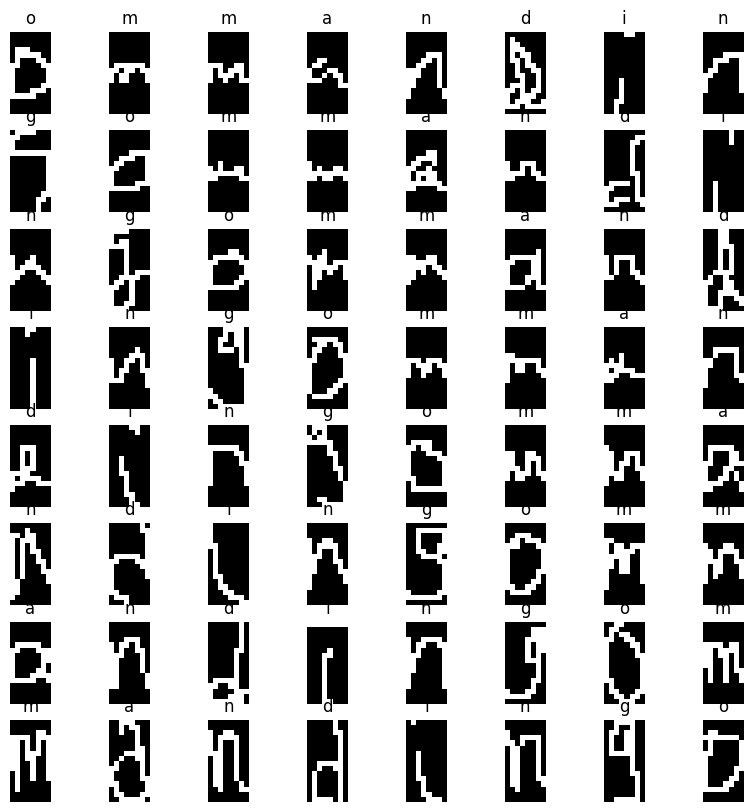

In [27]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

# Load dataset
letters_X = np.load('letters_X.npy')
letters_Y = np.load('letters_Y.npy')
imsize = (16,8)

plt.figure(figsize=(10,10))
for i in range(64):
    plt.subplot(8,8,i+1)
    plt.imshow(letters_X[i].reshape(imsize), cmap=plt.cm.gray)
    plt.title(chr(97+letters_Y[i].argmax()))
    plt.axis('off')
plt.show()

## Creating training and test sets

Split this dataset into a **training set**, a **validation set** and a **test set**. 

How can you make sure that they all share the same prior probability distribution ?

In [28]:
from sklearn.model_selection import train_test_split

# To make sure the three sets share the same prior probability distribution,
# we use a STRATIFIED split: each class keeps the same proportion in the
# train / validation / test sets as in the full dataset. We stratify on the
# integer class labels (argmax of the one-hot vectors).
labels = letters_Y.argmax(axis=1)

# First split: 70% training, 30% temporary (= validation + test)
X_train, X_temp, Y_train, Y_temp = train_test_split(
    letters_X, letters_Y, test_size=0.3, stratify=labels, random_state=0)

# Second split: cut the 30% in half -> 15% validation, 15% test
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.5, stratify=Y_temp.argmax(axis=1), random_state=0)

print("Training set   :", X_train.shape[0], "letters")
print("Validation set :", X_val.shape[0], "letters")
print("Test set       :", X_test.shape[0], "letters")


Training set   : 36506 letters
Validation set : 7823 letters
Test set       : 7823 letters


## Creating a Deep Neural Network with TensorFlow : a fake example

[TensorFlow](https://www.tensorflow.org/) is an "open source machine learning framework". It contains many operations which allow us to build, train and run Deep Neural Networks and to take full advantage of GPU acceleration.

The process of creating a neural network with TensorFlow contains different steps :

1. Creating the "Network Graph"
2. Defining the cost function and the optimizer
3. Training the network on the training set
4. Evaluating the network on the test

### Creating the "Network Graph"

The Network Graph contains all the operations that will be used for learning and in production. The network is built by "layers", connecting the output of an operation to the input of the next one. Let's use a simple example:

In [29]:
# This notebook uses the TensorFlow 1.x API (Session, placeholder, tf.layers...).
# TF 1.x has no build for this machine (arm64 / Python 3.9), so we run it on the
# v1 compatibility API of TensorFlow 2.x, in graph mode. Using the legacy Keras 2
# backend (tf-keras) is required for the tf.layers.* API used below to work.
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # hide TF's verbose INFO/WARNING C++ logs

import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

# Creating two "inputs"
a = tf.constant(1)
b = tf.constant(2)

# Creating an operation
c = tf.add(a, b)

print(a,b,c)

Tensor("Const:0", shape=(), dtype=int32) Tensor("Const_1:0", shape=(), dtype=int32) Tensor("Add_1:0", shape=(), dtype=int32)


An important thing to note is that, when building the graph, none of those operations are actually evaluated. We have just defined them. To execute graph operations, we have to define a session, and to evaluate the operation within the session :

In [30]:
sess = tf.Session()

c_evaluated = c.eval(session=sess)
print(c_evaluated)

3


An interesting type of element in the graph is the "placeholder". A placeholder can be defined as an object of a certain type and size, whose value will be given only during the evaluation. Let's reset the graph and recreate it with placeholders instead of the constant:

In [31]:
tf.reset_default_graph() # If we don't do that, we will keep adding new operations to the graph !

# Creating placeholder
a = tf.placeholder(tf.float32, shape=()) # Use shape = () if the object is a scalar
b = tf.placeholder(tf.float32, shape=())

# Creating opeartion
c = tf.add(a,b)

print(a,b,c)

Tensor("Placeholder:0", shape=(), dtype=float32) Tensor("Placeholder_1:0", shape=(), dtype=float32) Tensor("Add:0", shape=(), dtype=float32)


If we try to simply evaluate `c`, we will get an error: 
> "You must feed a value for placeholder tensor"

In [32]:
sess = tf.Session()

# This is MEANT to fail: c depends on the placeholders a and b, but we give them
# no value, so TensorFlow refuses to evaluate it. We catch the error here so it
# is only DISPLAYED (and a "Run All" does not stop on this teaching example).
try:
    print(c.eval(session=sess))
except tf.errors.InvalidArgumentError as e:
    print("As expected, we get an error because the placeholders were not fed:")
    print(e.message.splitlines()[0])

As expected, we get an error because the placeholders were not fed:
Graph execution error:


We can do that using the `feed_dict` argument of `eval`:

In [33]:
c_evaluated = c.eval(session=sess, feed_dict={a: 5, b: 3})
print(c_evaluated)

8.0


We can now start building something a bit more complex. The following example creates a network with the following characteristics :

* As **input**, a batch of 10x10x1 pixels images.
* One "**convolutional layer**" with 16 3x3 kernel and the "Leaky ReLU" activation function
* One operation to **flatten** the resulting "feature maps" into vectors
* One "**dense layer**" with as output a size 5 vector and the "Leaky ReLU" activation function
* One "**softmax**" layer applied at the end to get a "probability distribution" for the 5 "classes" 

In [34]:
tf.reset_default_graph()

X = tf.placeholder(tf.float32, [None, 10, 10, 1]) # "None" is interpreted in this case by TensorFlow as "unknown"
conv = tf.layers.conv2d(X, 16, 3, activation=tf.nn.leaky_relu, kernel_initializer=tf.variance_scaling_initializer())
print(conv.get_shape()) # What's the effect of the convolution on the shape of the output ? Why ?
flat = tf.layers.flatten(conv)
print(flat.get_shape())
dense = tf.layers.dense(flat, 5, activation=tf.nn.leaky_relu)
print(dense.get_shape())
softmax = tf.nn.softmax(dense)
print(softmax.get_shape())

(?, 8, 8, 16)
(?, 1024)
(?, 5)
(?, 5)


/var/folders/3v/7qmm1wrn4svcfm1hdpf_22lw0000gn/T/ipykernel_62768/476962115.py:4: UserWarning: `tf.layers.conv2d` is deprecated and will be removed in a future version. Please Use `tf.keras.layers.Conv2D` instead.
  conv = tf.layers.conv2d(X, 16, 3, activation=tf.nn.leaky_relu, kernel_initializer=tf.variance_scaling_initializer())
/var/folders/3v/7qmm1wrn4svcfm1hdpf_22lw0000gn/T/ipykernel_62768/476962115.py:6: UserWarning: `tf.layers.flatten` is deprecated and will be removed in a future version. Please use `tf.keras.layers.Flatten` instead.
  flat = tf.layers.flatten(conv)
/var/folders/3v/7qmm1wrn4svcfm1hdpf_22lw0000gn/T/ipykernel_62768/476962115.py:8: UserWarning: `tf.layers.dense` is deprecated and will be removed in a future version. Please use `tf.keras.layers.Dense` instead.
  dense = tf.layers.dense(flat, 5, activation=tf.nn.leaky_relu)


If we want to evaluate the "ouput" of our network, we must give as input a batch of 10x10x1 images. Let's create 2 random images, and get the output :

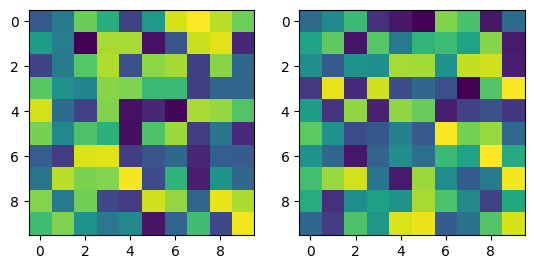

[[0.16080895 0.18205741 0.2669854  0.2270309  0.16311735]
 [0.13911784 0.15380427 0.40928158 0.16127315 0.13652314]]


In [35]:
Xrand = np.random.random((2,10,10,1))
# Show the two images:
plt.figure()
plt.subplot(1,2,1)
plt.imshow(Xrand[0,:,:,0])
plt.subplot(1,2,2)
plt.imshow(Xrand[1,:,:,0])
plt.show()

sess = tf.Session()
sess.run(tf.global_variables_initializer())
output = softmax.eval(session=sess, feed_dict={X: Xrand})
print(output)

### Defining the cost function and the optimizer

As we can see, for each of the two "images", we have a size-5 "output" vector. This is of course at the moment all meaningless, unless we train this network to actually *do* something.

In a supervised problem, we have *two* inputs: the images, and the target output. We also have a cost function which compares the "target" and the "prediction". In classification problems, the most common cost function is the cross-entropy. In regression problems, it's the mean square error. Let's create the target and the cross-entropy cost function:

In [36]:
target = tf.placeholder(tf.float32, [None, 5]) # Target must have the same shape as the output
cost = tf.nn.softmax_cross_entropy_with_logits(labels=target, logits=dense) 
# Note that the "softmax cross entropy" function already does the "softmax" operation, so we don't do logits=softmax but logits=dense.
print(cost.get_shape())

Instructions for updating:

Future major versions of TensorFlow will allow gradients to flow
into the labels input on backprop by default.

See `tf.nn.softmax_cross_entropy_with_logits_v2`.

(?,)


As we can see, this computes a cost "per image". When training a neural network, we want to have a cost "per batch", which will usually be simply the mean value of the "per image" cost:

In [37]:
cost_avg = tf.reduce_mean(cost)
print(cost_avg.get_shape())

()


Finally, we have to define the optimizer. Tensorflow provides different options, which are all variants of the simple Gradient Descent algorithm. We will use here the "Adam" optimizer, which tend to perform well. With this optimizer, we can define the "training step" of the algorithm, meaning "what the training algorithm must do at each iteration". In this case, we want to use the optimizer to minimize the cost function:

In [38]:
optimizer = tf.train.AdamOptimizer()
trainingStep = optimizer.minimize(cost_avg)

### Training the network on the training set

Right now, we don't have a training set for this fake network. Let's quickly generate one, with some simple rules:

* We will generate 1000 images
* Each image will be assigned to a random class
* Depending on the class, there will be some empty pixels in the image (0 = top-left corner, 1 = top-right, ..., 4 = none)

In [39]:
N = 1000

fake_train_class = (np.random.random((N,))*5).astype('int')
fake_train_target = np.zeros((N,5))
fake_train_images = np.random.random((N,10,10,1))

for i in range(N):
    c = fake_train_class[i]
    fake_train_target[i,c] = 1
    if( c == 0 ):
        fake_train_images[i,:5,:5,0] = 0
    elif( c== 1 ):
        fake_train_images[i,:5,5:,0] = 0
    elif( c== 2 ):
        fake_train_images[i,5:,:5,0] = 0
    elif( c== 3 ):
        fake_train_images[i,5:,5:,0] = 0

Now let's use this training set to train our network. We will use a batch size of 10 (meaning that the network is trained on 10 images at a time), and go through all images once (= "trained for 1 epoch").

In [40]:
BATCH_SIZE = 10
EPOCHS = 1

# Reset session
sess = tf.Session()
sess.run(tf.global_variables_initializer())

for e in range(EPOCHS):
    for i in range(N//BATCH_SIZE):
        # Load batch
        batch_X = fake_train_images[i*BATCH_SIZE:(i+1)*BATCH_SIZE]
        batch_Y = fake_train_target[i*BATCH_SIZE:(i+1)*BATCH_SIZE]

        # Perform training step
        trainingStep.run(session=sess, feed_dict={X: batch_X, target: batch_Y})

### Evaluating the network on the test set

The network has been "trained", but we have no idea how well it performs ! To do that, we should generate a test set which we will use to see if the network prediction matches the target. As we are generating the examples, we can make as many as we like, so we will also use 1000:

In [41]:
fake_test_class = (np.random.random((N,))*5).astype('int')
fake_test_target = np.zeros((N,5))
fake_test_images = np.random.random((N,10,10,1))

for i in range(N):
    c = fake_test_class[i]
    fake_test_target[i,c] = 1
    if( c == 0 ):
        fake_test_images[i,:5,:5,0] = 0
    elif( c== 1 ):
        fake_test_images[i,:5,5:,0] = 0
    elif( c== 2 ):
        fake_test_images[i,5:,:5,0] = 0
    elif( c== 3 ):
        fake_test_images[i,5:,5:,0] = 0

We can get the prediction of the network for the entire set (if the network was bigger, we would probably have to do the prediction in batches...)

In [42]:
test_predicted = softmax.eval(session=sess, feed_dict={X: fake_test_images})

The "predicted class" will be the index of the highest value of the size 5 vector after the softmax operation. We can get it using the argmax operation:

In [43]:
print(test_predicted.shape)
test_predicted_class = test_predicted.argmax(axis=1)
print(test_predicted_class.shape)
print(fake_test_class.shape)

(1000, 5)
(1000,)
(1000,)


To get the global accuracy of the test, we can just compare the predicted class vector with the target class vector :

In [44]:
accuracy = (test_predicted_class==fake_test_class).sum()/len(test_predicted_class)
print("Accuracy : %.2f%%"%(accuracy*100))

Accuracy : 100.00%


This is very good, but the problem was extremely easy. However, you now have everything you need to create your network and apply it to the OCR problem.

## Solving the OCR dataset

Using as a template the code from the previous exercise, provided below for simplicity, create a network which will work on the OCR problem.

In [45]:
tf.reset_default_graph()

# Prepare the OCR data: reshape the flat 128-vectors into 16x8x1 images
# and cast everything to float32.
train_images = X_train.reshape(-1, 16, 8, 1).astype('float32')
test_images  = X_test.reshape(-1, 16, 8, 1).astype('float32')
train_target = Y_train.astype('float32')
test_class   = Y_test.argmax(axis=1)

# Building the network: input is now 16x8x1, output is 26 classes (a..z)
X = tf.placeholder(tf.float32, [None, 16, 8, 1])
conv = tf.layers.conv2d(X, 16, 3, activation=tf.nn.leaky_relu, kernel_initializer=tf.variance_scaling_initializer())
flat = tf.layers.flatten(conv)
dense = tf.layers.dense(flat, 26, activation=tf.nn.leaky_relu)
softmax = tf.nn.softmax(dense)

# Preparing the training operation
target = tf.placeholder(tf.float32, [None, 26]) # Target must have the same shape as the output
cost = tf.nn.softmax_cross_entropy_with_logits(labels=target, logits=dense)
cost_avg = tf.reduce_mean(cost)
optimizer = tf.train.AdamOptimizer()
trainingStep = optimizer.minimize(cost_avg)

# Train the network
BATCH_SIZE = 100
N = train_images.shape[0]
EPOCHS = 10

sess = tf.Session()
sess.run(tf.global_variables_initializer())

for e in range(EPOCHS):
    for i in range(N//BATCH_SIZE):
        # Load batch
        batch_X = train_images[i*BATCH_SIZE:(i+1)*BATCH_SIZE]
        batch_Y = train_target[i*BATCH_SIZE:(i+1)*BATCH_SIZE]

        # Perform training step
        trainingStep.run(session=sess, feed_dict={X: batch_X, target: batch_Y})

# Test the network
test_predicted = softmax.eval(session=sess, feed_dict={X: test_images})
test_predicted_class = test_predicted.argmax(axis=1)

accuracy = (test_predicted_class==test_class).sum()/len(test_predicted_class)
print("Test accuracy : %.2f%%"%(accuracy*100))


/var/folders/3v/7qmm1wrn4svcfm1hdpf_22lw0000gn/T/ipykernel_62768/1252989970.py:12: UserWarning: `tf.layers.conv2d` is deprecated and will be removed in a future version. Please Use `tf.keras.layers.Conv2D` instead.
  conv = tf.layers.conv2d(X, 16, 3, activation=tf.nn.leaky_relu, kernel_initializer=tf.variance_scaling_initializer())
/var/folders/3v/7qmm1wrn4svcfm1hdpf_22lw0000gn/T/ipykernel_62768/1252989970.py:13: UserWarning: `tf.layers.flatten` is deprecated and will be removed in a future version. Please use `tf.keras.layers.Flatten` instead.
  flat = tf.layers.flatten(conv)
/var/folders/3v/7qmm1wrn4svcfm1hdpf_22lw0000gn/T/ipykernel_62768/1252989970.py:14: UserWarning: `tf.layers.dense` is deprecated and will be removed in a future version. Please use `tf.keras.layers.Dense` instead.
  dense = tf.layers.dense(flat, 26, activation=tf.nn.leaky_relu)


Test accuracy : 87.60%


## Using TensorBoard for visualisation and monitoring

TensorBoard is a tool provided alongside TensorFlow to make it easier to inspect a network and follow the learning process. During the graph creation process, it's possible to add "[summaries](https://www.tensorflow.org/guide/summaries_and_tensorboard)", which can track the evolution of the loss, of weights, or any other measure you may be interested in. The summaries will also include a representation of the graph, which is useful to visualize (and debug) the network. 

Using the example below, which adds a summary to the fake test network, add a summary for the cost of your OCR network.

To start tensorboard, open the *Anaconda Prompt* and go to the directory where this file is located, then execute the command:

```
tensorboard --logdir=./summary
```

You'll then be able to access TensorBoard from your browser.

**Where would you use the "validation set" in the OCR data?**

In [46]:
import os

# Where would you use the validation set in the OCR data?
# -> The validation set is used DURING training (here, after each epoch) to
#    monitor how well the network generalises to data it was not trained on.
#    It lets us tune hyper-parameters and decide when to stop training (early
#    stopping / model selection) WITHOUT ever looking at the test set, which is
#    kept untouched for the final, unbiased evaluation.

tf.reset_default_graph()

# Data
train_images = X_train.reshape(-1, 16, 8, 1).astype('float32')
val_images   = X_val.reshape(-1, 16, 8, 1).astype('float32')
test_images  = X_test.reshape(-1, 16, 8, 1).astype('float32')
train_target = Y_train.astype('float32')
val_class    = Y_val.argmax(axis=1)
test_class   = Y_test.argmax(axis=1)

# Building the network
X = tf.placeholder(tf.float32, [None, 16, 8, 1])
conv = tf.layers.conv2d(X, 16, 3, activation=tf.nn.leaky_relu, kernel_initializer=tf.variance_scaling_initializer())
flat = tf.layers.flatten(conv)
dense = tf.layers.dense(flat, 26, activation=tf.nn.leaky_relu)
softmax = tf.nn.softmax(dense)

# Preparing the training operation
target = tf.placeholder(tf.float32, [None, 26]) # Target must have the same shape as the output
cost = tf.nn.softmax_cross_entropy_with_logits(labels=target, logits=dense)
cost_avg = tf.reduce_mean(cost)
optimizer = tf.train.AdamOptimizer()
trainingStep = optimizer.minimize(cost_avg)

# Train the network
BATCH_SIZE = 100
N = train_images.shape[0]
EPOCHS = 10

sess = tf.Session()

# Create Summary for the cost
tf.summary.scalar('cost_avg', cost_avg)
merged = tf.summary.merge_all()

# Create "summary" directory if it doesn't exist
if( not os.path.isdir('summary') ):
    os.mkdir('summary')

train_writer = tf.summary.FileWriter('summary', sess.graph)

sess.run(tf.global_variables_initializer())

step = 0
for e in range(EPOCHS):
    for i in range(N//BATCH_SIZE):
        # Load batch
        batch_X = train_images[i*BATCH_SIZE:(i+1)*BATCH_SIZE]
        batch_Y = train_target[i*BATCH_SIZE:(i+1)*BATCH_SIZE]

        # Perform training step
        trainingStep.run(session=sess, feed_dict={X: batch_X, target: batch_Y})

        # Summary writing:
        summ = sess.run(merged, feed_dict={X: batch_X, target: batch_Y})
        train_writer.add_summary(summ, step)
        step += 1

    # Use of the validation set: check generalisation at the end of each epoch
    val_predicted = softmax.eval(session=sess, feed_dict={X: val_images})
    val_acc = (val_predicted.argmax(axis=1)==val_class).sum()/len(val_class)
    print("Epoch %d - validation accuracy : %.2f%%"%(e+1, val_acc*100))

# Test the network
test_predicted = softmax.eval(session=sess, feed_dict={X: test_images})
test_predicted_class = test_predicted.argmax(axis=1)

accuracy = (test_predicted_class==test_class).sum()/len(test_predicted_class)
print("Test accuracy : %.2f%%"%(accuracy*100))


/var/folders/3v/7qmm1wrn4svcfm1hdpf_22lw0000gn/T/ipykernel_62768/47555116.py:22: UserWarning: `tf.layers.conv2d` is deprecated and will be removed in a future version. Please Use `tf.keras.layers.Conv2D` instead.
  conv = tf.layers.conv2d(X, 16, 3, activation=tf.nn.leaky_relu, kernel_initializer=tf.variance_scaling_initializer())
/var/folders/3v/7qmm1wrn4svcfm1hdpf_22lw0000gn/T/ipykernel_62768/47555116.py:23: UserWarning: `tf.layers.flatten` is deprecated and will be removed in a future version. Please use `tf.keras.layers.Flatten` instead.
  flat = tf.layers.flatten(conv)
/var/folders/3v/7qmm1wrn4svcfm1hdpf_22lw0000gn/T/ipykernel_62768/47555116.py:24: UserWarning: `tf.layers.dense` is deprecated and will be removed in a future version. Please use `tf.keras.layers.Dense` instead.
  dense = tf.layers.dense(flat, 26, activation=tf.nn.leaky_relu)


Epoch 1 - validation accuracy : 77.22%
Epoch 2 - validation accuracy : 81.64%
Epoch 3 - validation accuracy : 83.84%
Epoch 4 - validation accuracy : 85.13%
Epoch 5 - validation accuracy : 85.94%
Epoch 6 - validation accuracy : 86.17%
Epoch 7 - validation accuracy : 86.65%
Epoch 8 - validation accuracy : 86.92%
Epoch 9 - validation accuracy : 87.20%
Epoch 10 - validation accuracy : 87.42%
Test accuracy : 87.81%


## Saving and  loading networks

For a network to be useful, we need to be able to save it, and to reload it so that it can be trained once and reused as necessary. The following code shows how to save the network, load it, and access the placeholders & output necessary for inference, once again using our fake example. You should modify this code to do the same with the OCR network.

In [47]:
import os

tf.reset_default_graph()

# Data
train_images = X_train.reshape(-1, 16, 8, 1).astype('float32')
train_target = Y_train.astype('float32')

# Building the network
X = tf.placeholder(tf.float32, [None, 16, 8, 1])
conv = tf.layers.conv2d(X, 16, 3, activation=tf.nn.leaky_relu, kernel_initializer=tf.variance_scaling_initializer())
flat = tf.layers.flatten(conv)
dense = tf.layers.dense(flat, 26, activation=tf.nn.leaky_relu)
softmax = tf.nn.softmax(dense)

# Preparing the training operation
target = tf.placeholder(tf.float32, [None, 26]) # Target must have the same shape as the output
cost = tf.nn.softmax_cross_entropy_with_logits(labels=target, logits=dense)
cost_avg = tf.reduce_mean(cost)
optimizer = tf.train.AdamOptimizer()
trainingStep = optimizer.minimize(cost_avg)

# Train the network
BATCH_SIZE = 100
N = train_images.shape[0]
EPOCHS = 10

sess = tf.Session()

# Create Summary for the cost
tf.summary.scalar('cost_avg', cost_avg)
merged = tf.summary.merge_all()

# Create "summary" directory if it doesn't exist
if( not os.path.isdir('summary') ):
    os.mkdir('summary')

train_writer = tf.summary.FileWriter('summary', sess.graph)

# Create "Saver"
saver = tf.train.Saver()

sess.run(tf.global_variables_initializer())

step = 0
for e in range(EPOCHS):
    for i in range(N//BATCH_SIZE):
        # Load batch
        batch_X = train_images[i*BATCH_SIZE:(i+1)*BATCH_SIZE]
        batch_Y = train_target[i*BATCH_SIZE:(i+1)*BATCH_SIZE]

        # Perform training step
        trainingStep.run(session=sess, feed_dict={X: batch_X, target: batch_Y})

        # Summary writing:
        summ = sess.run(merged, feed_dict={X: batch_X, target: batch_Y})
        train_writer.add_summary(summ, step)
        step += 1

# Save trained network
saver.save(sess, "./ocr_network.ckpt") # .ckpt = tensorflow "checkpoint" files.


/var/folders/3v/7qmm1wrn4svcfm1hdpf_22lw0000gn/T/ipykernel_62768/3374984219.py:11: UserWarning: `tf.layers.conv2d` is deprecated and will be removed in a future version. Please Use `tf.keras.layers.Conv2D` instead.
  conv = tf.layers.conv2d(X, 16, 3, activation=tf.nn.leaky_relu, kernel_initializer=tf.variance_scaling_initializer())
/var/folders/3v/7qmm1wrn4svcfm1hdpf_22lw0000gn/T/ipykernel_62768/3374984219.py:12: UserWarning: `tf.layers.flatten` is deprecated and will be removed in a future version. Please use `tf.keras.layers.Flatten` instead.
  flat = tf.layers.flatten(conv)
/var/folders/3v/7qmm1wrn4svcfm1hdpf_22lw0000gn/T/ipykernel_62768/3374984219.py:13: UserWarning: `tf.layers.dense` is deprecated and will be removed in a future version. Please use `tf.keras.layers.Dense` instead.
  dense = tf.layers.dense(flat, 26, activation=tf.nn.leaky_relu)


'./ocr_network.ckpt'

We can load specific operations or tensors in the graph once it has been restored. To get the name of the operation we need, we can check the graph in TensorBoard. Alternatively, we can define the names when building the graph. We could for instance have written: `X = tf.placeholder(tf.float32, [None, 10, 10, 1], name='X')`, in which case we would access the operation with `X = tf.get_default_graph().get_operation_by_name('X')`.

In [48]:
# Load trained network
tf.reset_default_graph()
sess = tf.Session()

saver = tf.train.import_meta_graph("./ocr_network.ckpt.meta") # Restore graph
saver.restore(sess, "./ocr_network.ckpt") # Restore weights

# Load placeholder:
X = tf.get_default_graph().get_operation_by_name('Placeholder').outputs[0]
# Load network output
output = tf.get_default_graph().get_operation_by_name('Softmax').outputs[0]

# Test the network on the OCR test set
test_images = X_test.reshape(-1, 16, 8, 1).astype('float32')
test_class  = Y_test.argmax(axis=1)

test_predicted = output.eval(session=sess, feed_dict={X: test_images})
test_predicted_class = test_predicted.argmax(axis=1)

accuracy = (test_predicted_class==test_class).sum()/len(test_predicted_class)
print("Test accuracy (reloaded network) : %.2f%%"%(accuracy*100))


INFO:tensorflow:Restoring parameters from ./ocr_network.ckpt
Test accuracy (reloaded network) : 87.59%
